In [9]:
import math
import random
import os

import numpy as np
import pandas as pd
pd.set_option('display.max_rows', 500)

import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 16,          # 默认文字
    "axes.titlesize": 16,     # 标题
    "axes.labelsize": 16,     # 坐标轴标签
    "xtick.labelsize": 16,    # x 轴刻度
    "ytick.labelsize": 16,    # y 轴刻度
    "legend.fontsize": 16,    # 图例
})

In [10]:
# 数据读取
user_info_cols = ['user_id', 'video_id', 'time_ms', 'play_time_ms', 'duration_ms']
# 用户观看信息，包括 用户id，视频id，用户交互的时间戳，观看时长
user_info_p1 = pd.read_csv('data/KuaiRand-27K/log_standard_4_08_to_4_21_27k_part1.csv', usecols=user_info_cols)
user_info_p2 = pd.read_csv('data/KuaiRand-27K/log_standard_4_08_to_4_21_27k_part2.csv', usecols=user_info_cols)

user_info = pd.concat([user_info_p1, user_info_p2], ignore_index=True)

del user_info_p1
del user_info_p2

In [11]:
# video_info_cols = ['video_id', 'video_duration']
# # 视频基本信息，包括视频id，视频类型，视频时长
# video_info = pd.read_csv('data/KuaiRand-27K/video_features_basic_27k.csv', usecols=video_info_cols).dropna(subset=['video_duration'])

In [12]:
user_viewed_video_num = user_info['user_id'].value_counts()
print(user_viewed_video_num.describe())

random.seed(33)
user_id_for_hist = random.sample(list(user_viewed_video_num.head(10000).index), 20)
print(len(user_id_for_hist))
user_info_for_hist = user_info[user_info['user_id'].isin(user_id_for_hist)]

count     26904.000000
mean       5066.033898
std        5523.491689
min           1.000000
25%        1715.000000
50%        3487.500000
75%        6570.000000
max      120897.000000
Name: count, dtype: float64
20


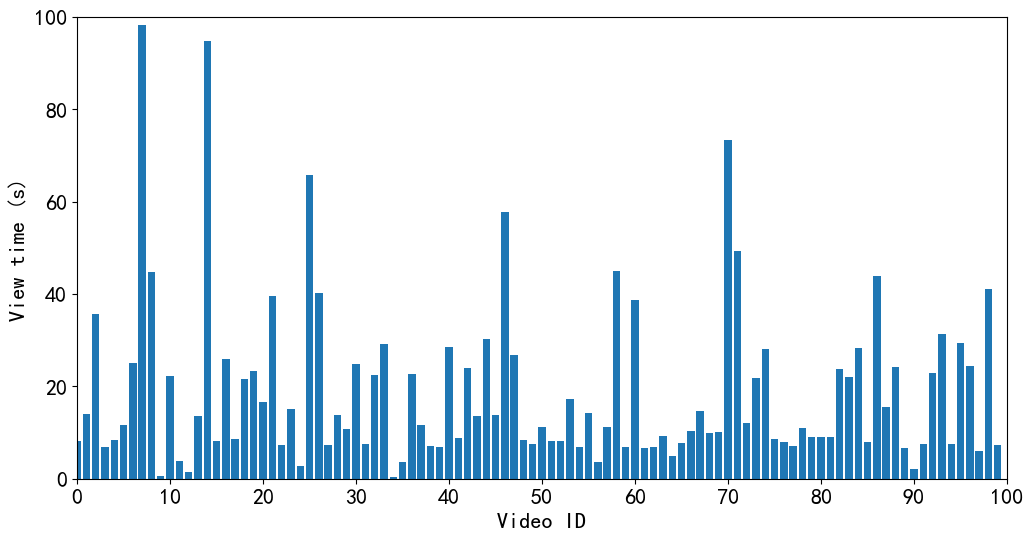

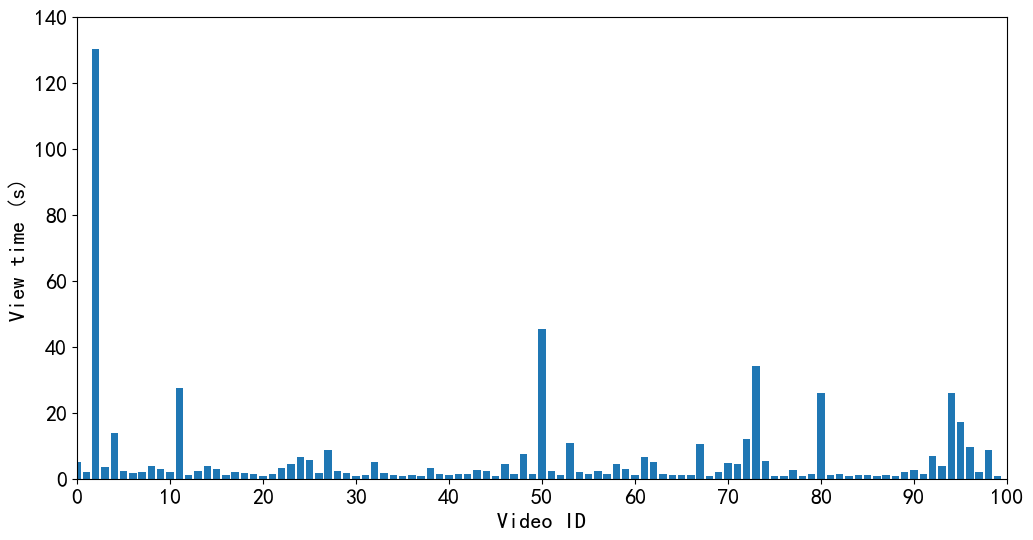

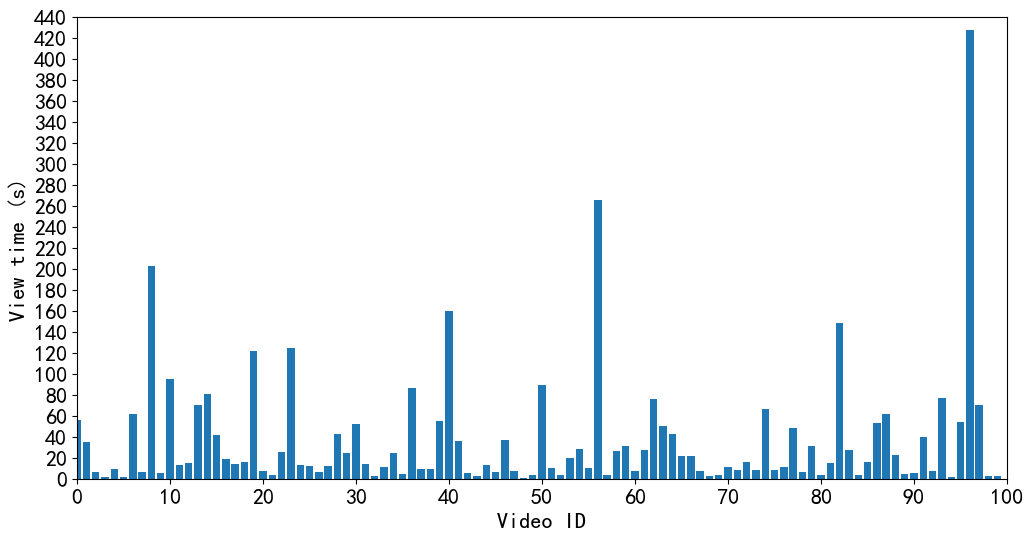

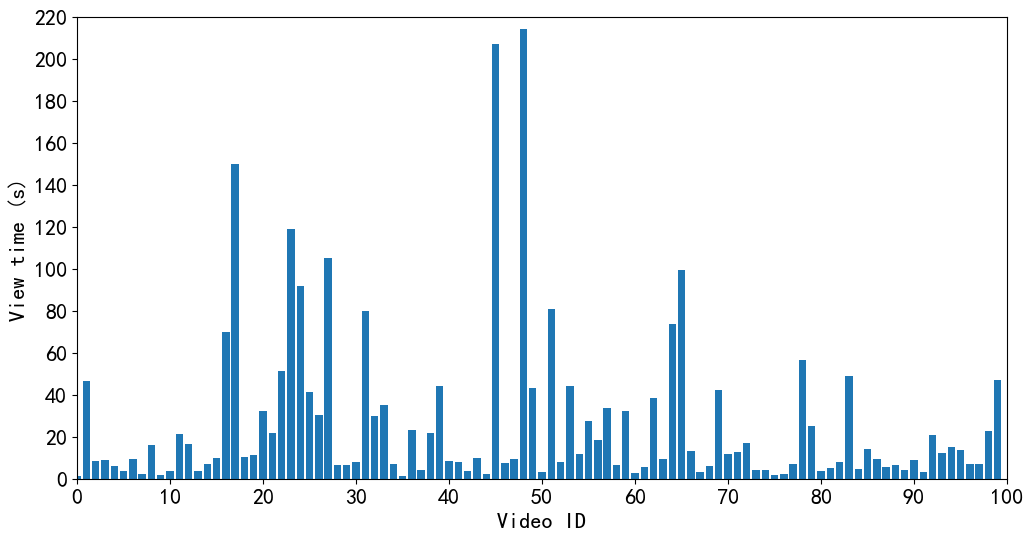

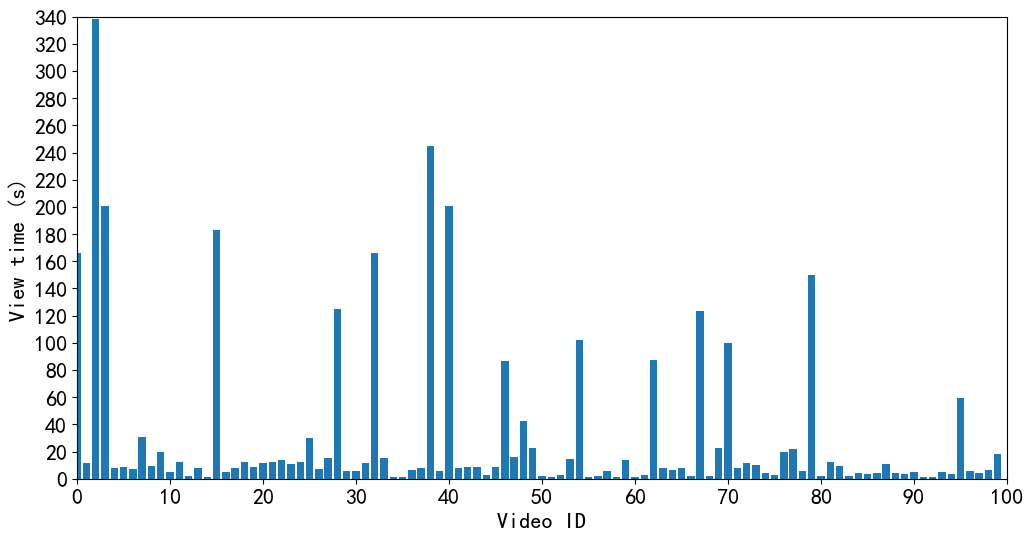

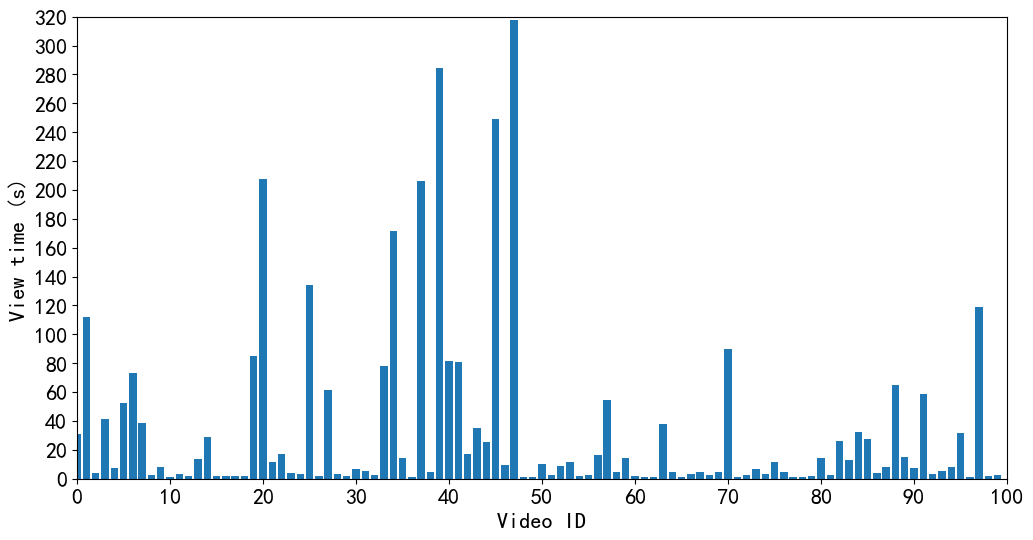

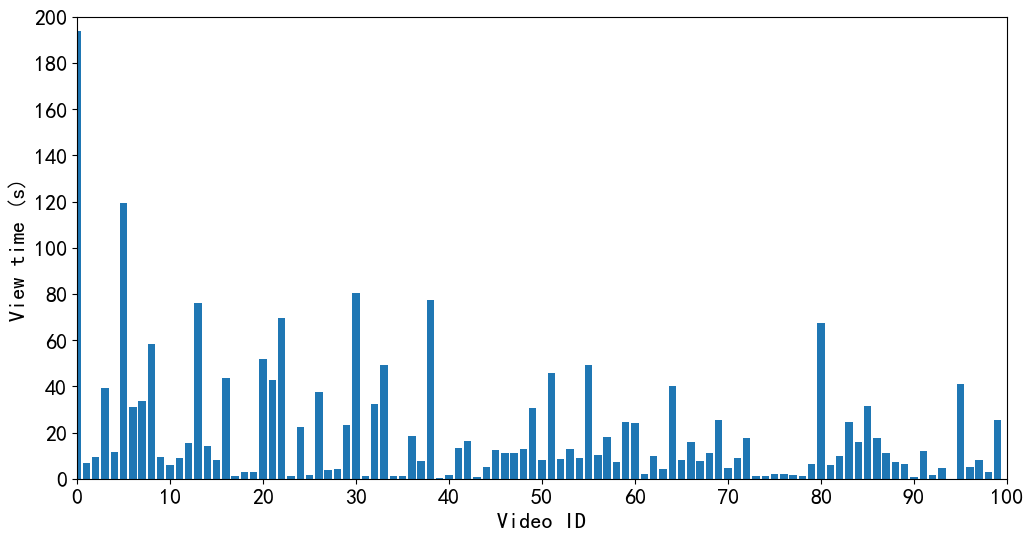

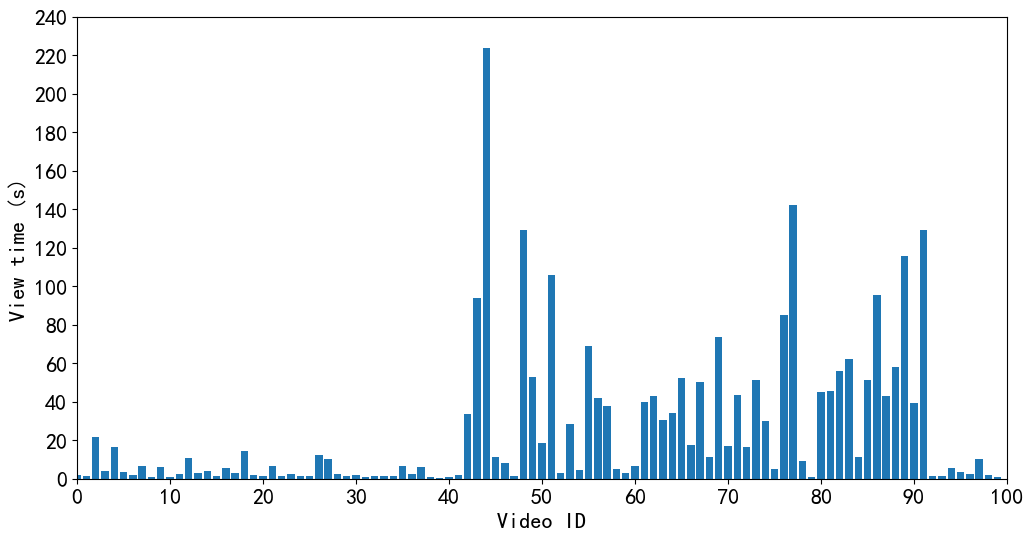

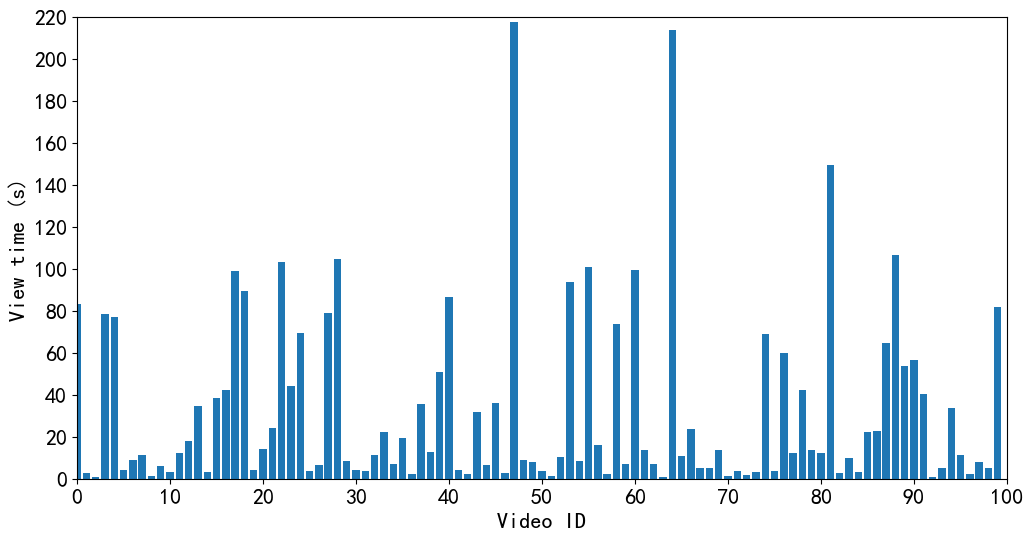

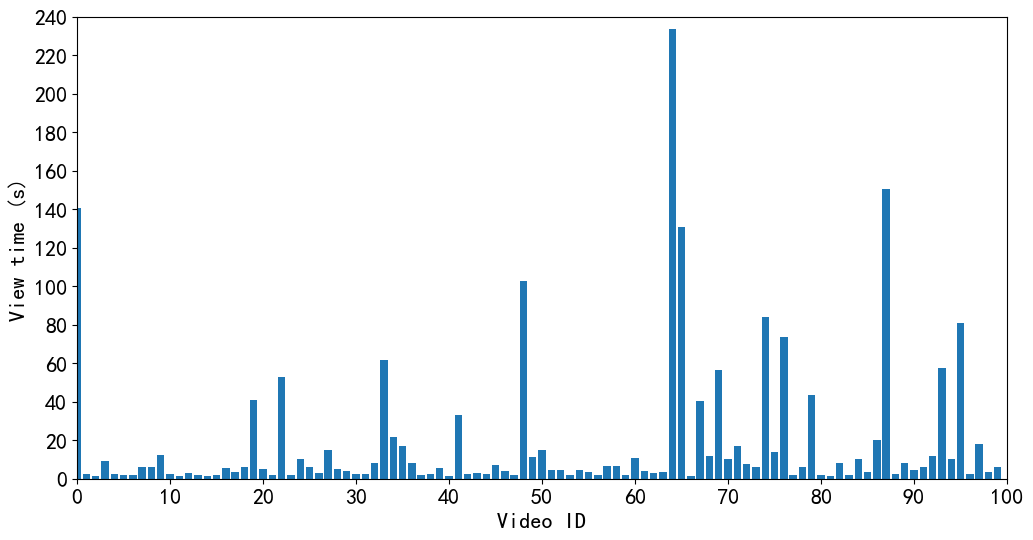

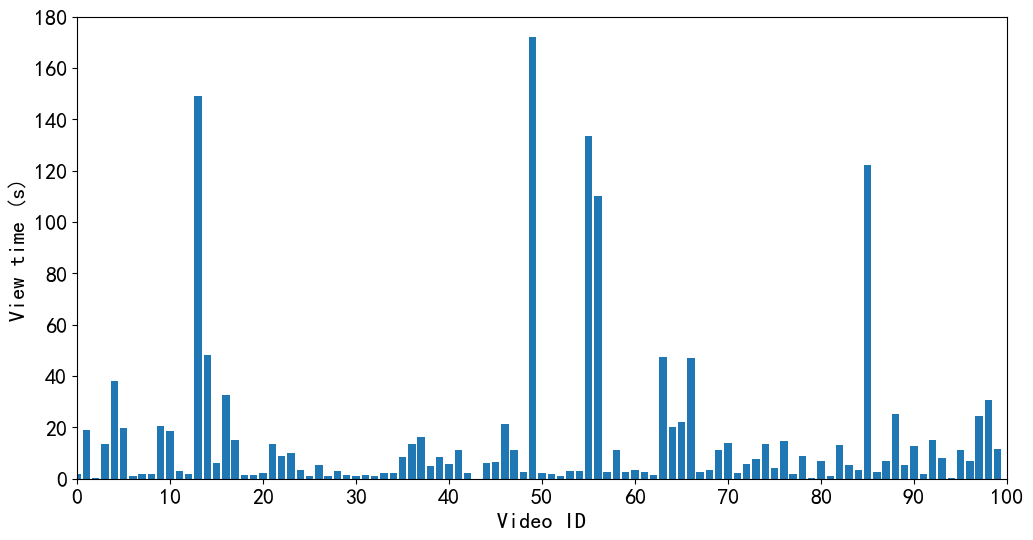

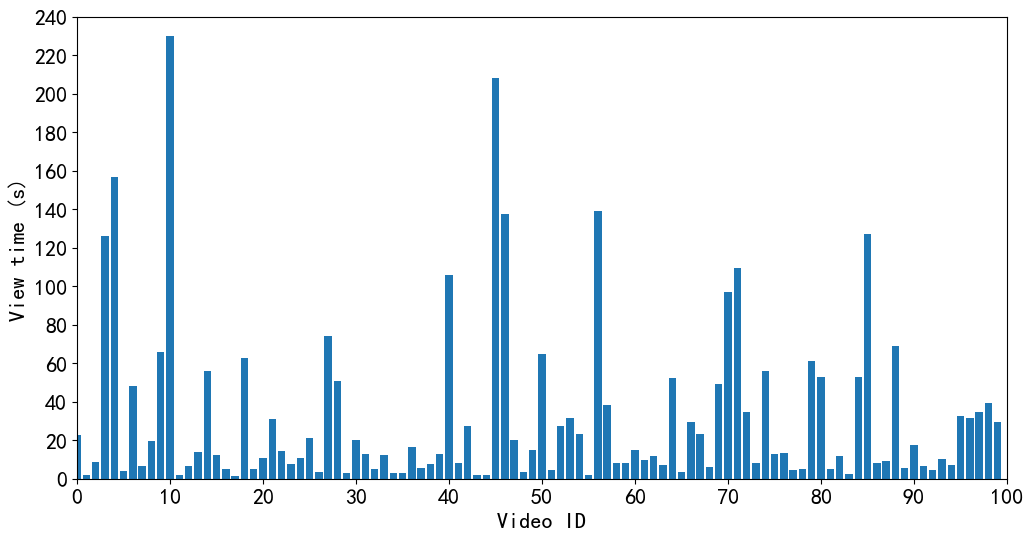

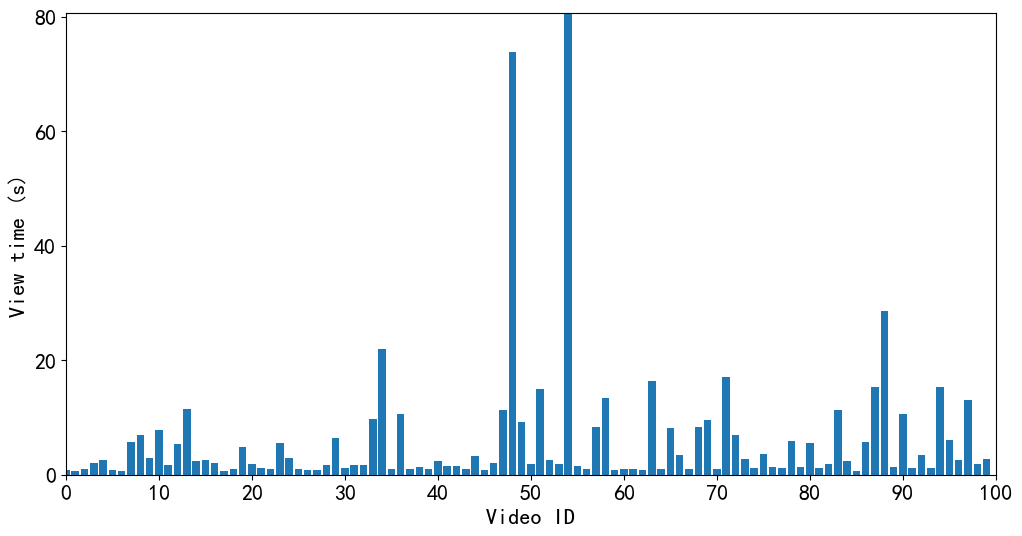

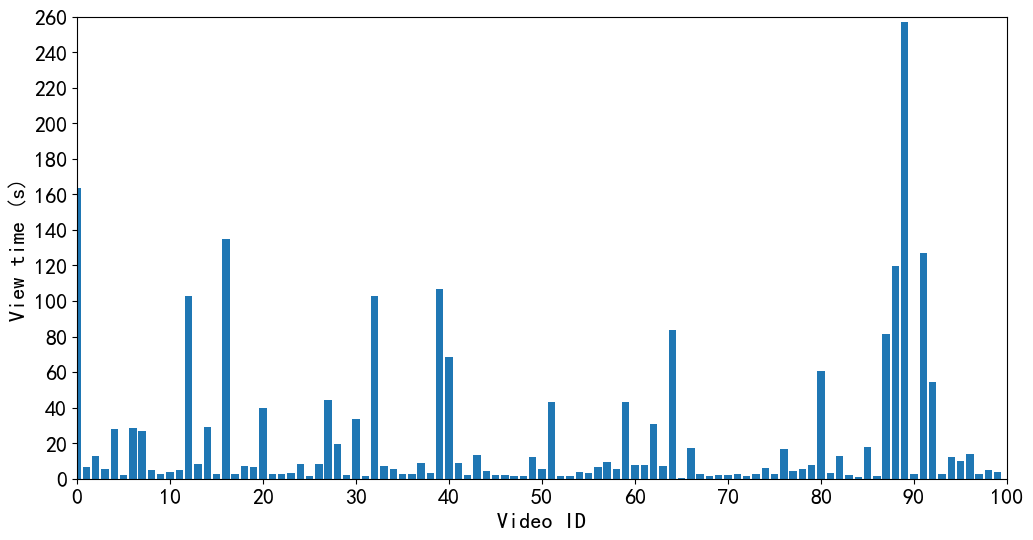

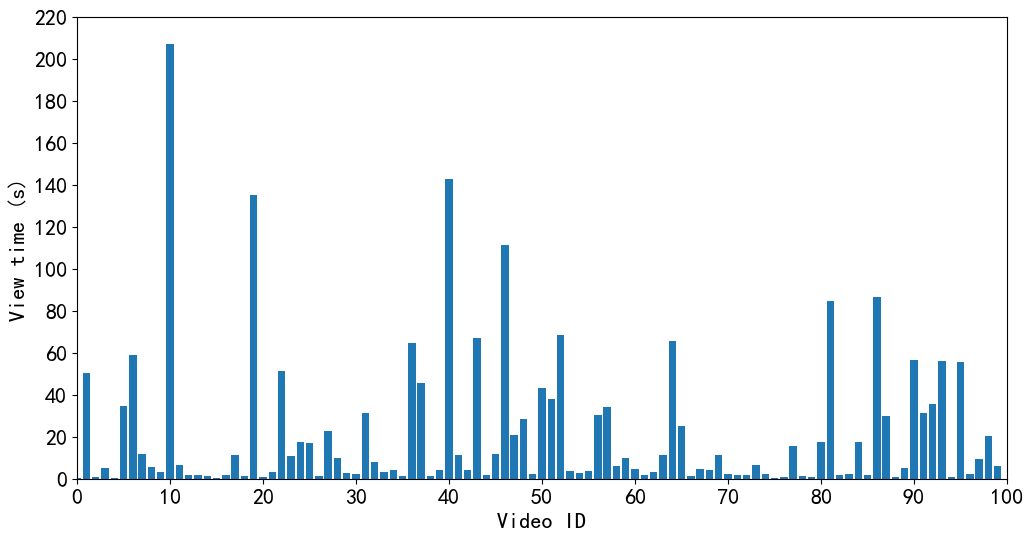

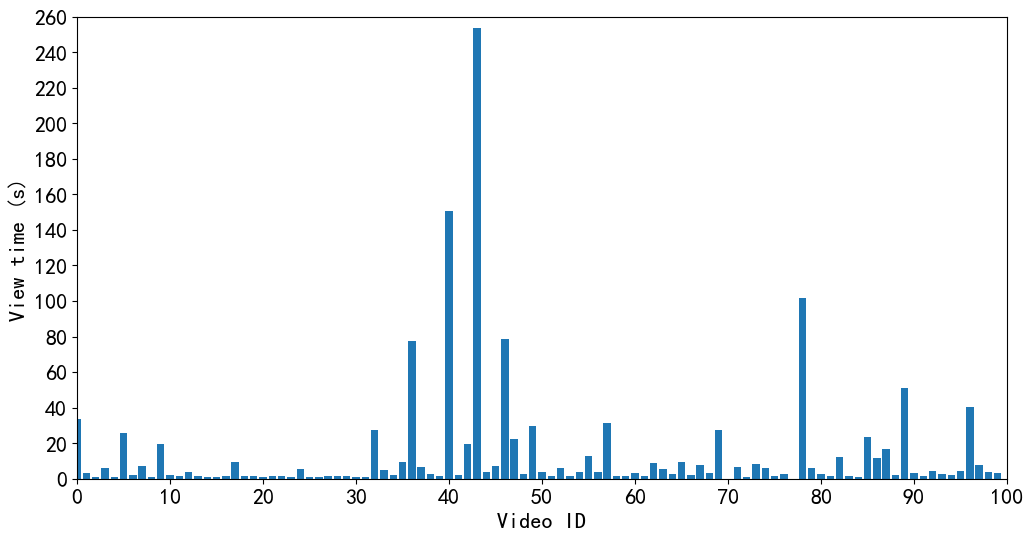

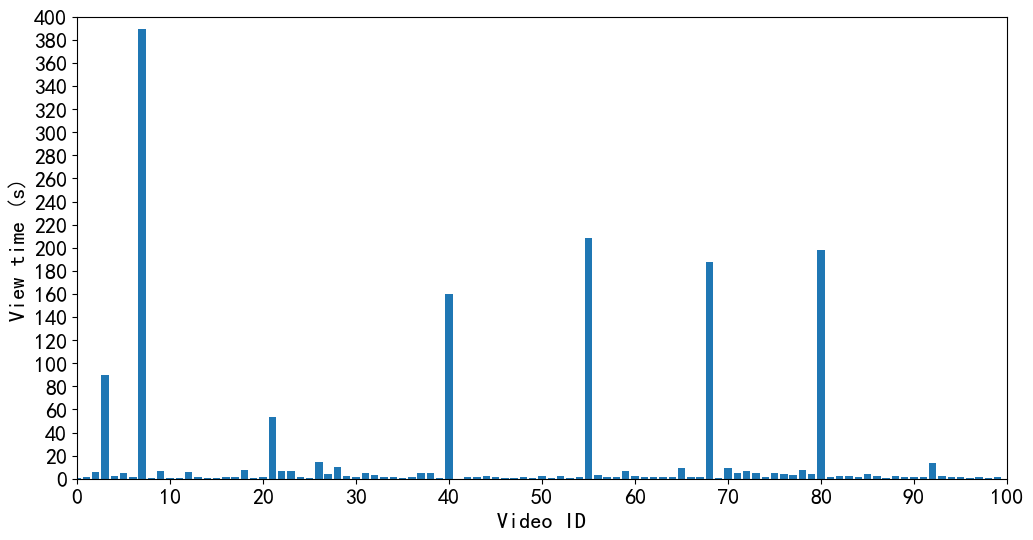

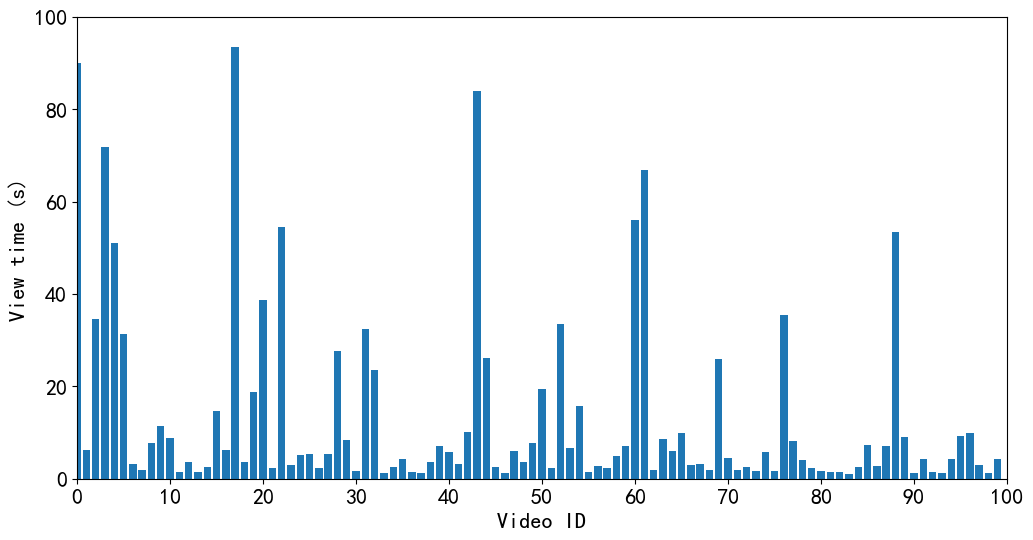

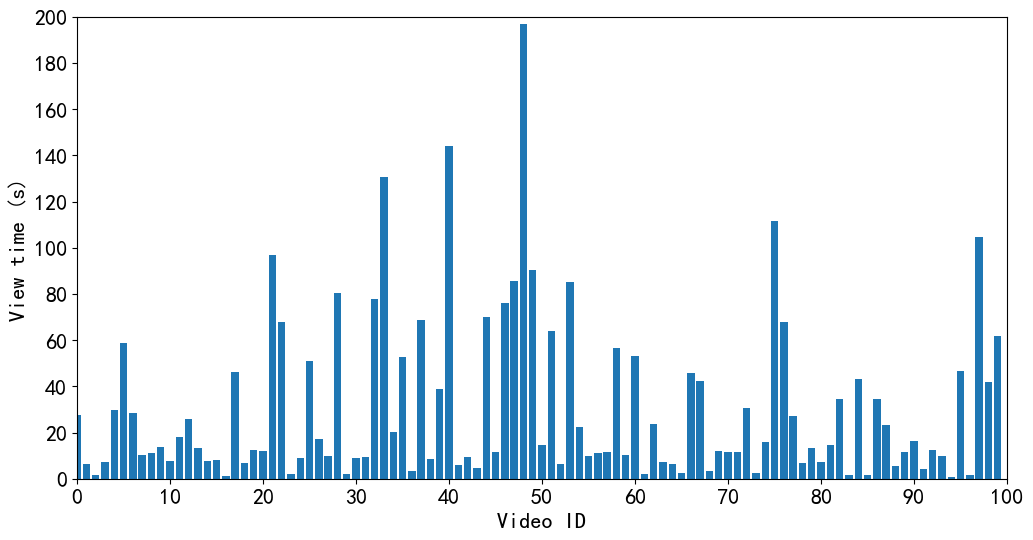

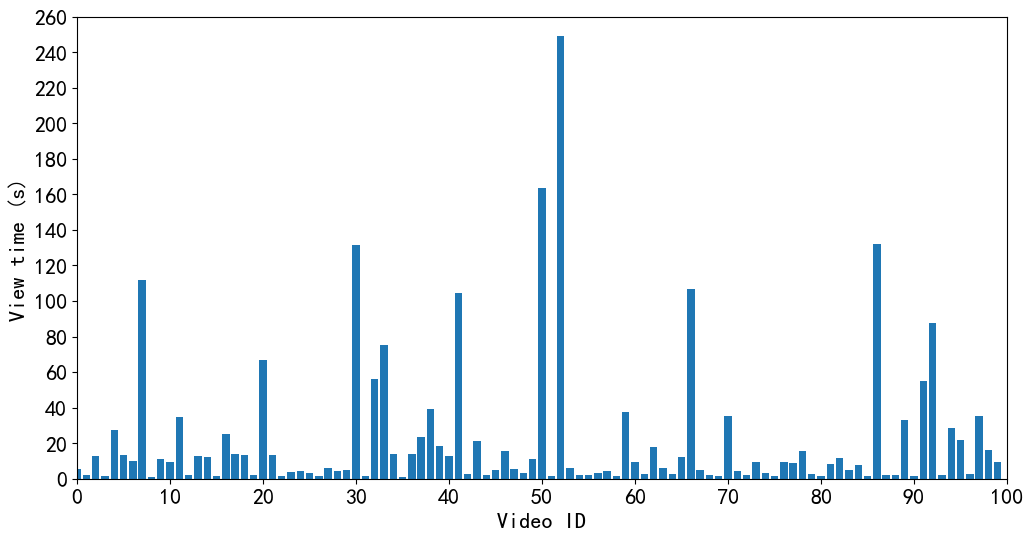

In [13]:
for user_id in user_id_for_hist:
    quick_switch_count = []
    view_time_threhold = 6000 # ms
    user_viewed_video_info = user_info_for_hist[user_info_for_hist['user_id'] == user_id]
    
    # 方案3，去除了图片，并限制最大观看时长为视频时长
    view_times = []
    for i in range(len(user_viewed_video_info)):
        viewed_video_info = user_viewed_video_info.iloc[i]
        video_duration = viewed_video_info['duration_ms']
        if video_duration == 0:
            continue
        else:
            view_time = min(viewed_video_info['play_time_ms'], video_duration.item()) / 1000.
            if view_time == 0:
                continue
            view_times.append(view_time)
            if len(view_times) >= 100:
                break
    plt.figure(figsize=(12, 6))            
    
    plt.ylim(0, max(view_times))
    plt.yticks(np.arange(0, max(view_times) + 19, 20))
    plt.ylabel('View time (s)')
    
    plt.xlim(0, 100)
    plt.xticks(np.arange(0, 101, 10))
    plt.xlabel('Video ID')
    plt.bar(range(100), view_times)
    plt.show()

[  0.      1.222   2.463   4.123   5.693   7.26    8.491   9.42   36.653
  41.829  43.924  53.174  59.54   62.115  63.875  66.038  85.76   89.594
  96.61  118.687 121.13  150.626 154.624 156.389 162.253 163.963 167.488
 180.478 184.182 215.746 217.454 218.98  222.35  223.862 232.6   238.1
 240.909 250.042 252.348 260.148 263.123 290.696 290.759 297.524 298.383
 306.749 312.747 314.323 316.806 316.905 322.905 325.283 326.974 339.164
 340.61  341.789 365.322 377.218 393.768 395.792 446.958 450.442 451.853
 456.032 458.62  460.99  465.531 506.164 514.107 518.119 521.177 523.198
 524.962 561.309 563.422 565.307 572.74  573.902 582.261 583.553 585.252
 593.265 594.429 600.793 607.5   609.584 611.457 620.657 625.076 632.476
 673.95  677.332 684.925 695.341 703.867 705.825 709.668 711.969 714.673
 726.873 737.617 738.867 751.787 753.934 757.512 765.347 773.147 774.987
 776.381 778.633 785.433 789.686 796.586 801.258 808.26  810.764 815.84
 822.577 824.321 876.709 878.178 886.597 907.789 908.9

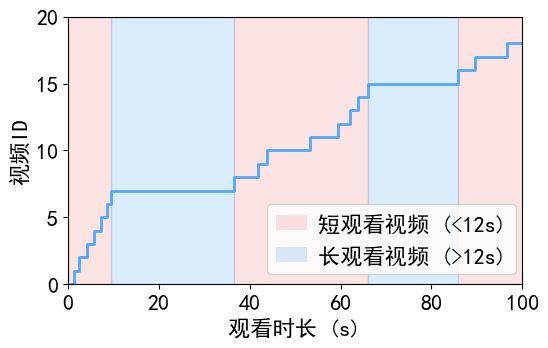

In [16]:
from matplotlib.patches import Patch

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

user_id = user_id_for_hist[15] #12
quick_switch_count = []
view_time_threhold = 6000 # ms
user_viewed_video_info = user_info_for_hist[user_info_for_hist['user_id'] == user_id]

# 方案3，去除了图片，并限制最大观看时长为视频时长
view_times = []
for i in range(len(user_viewed_video_info)):
    viewed_video_info = user_viewed_video_info.iloc[i]
    video_duration = viewed_video_info['duration_ms']

    if video_duration == 0:
        continue
    else:
        view_time = min(viewed_video_info['play_time_ms'], video_duration.item()) / 1000.
        if view_time == 0 or view_time > 60:
            continue
        view_times.append(view_time)
        if len(view_times) >= 150:
            break
            
view_times = np.array(view_times)

colors = [
    (239 / 255, 118 / 255, 123 / 255),
    (67 / 255, 163 / 255, 239 / 255),
]

fig, ax = plt.subplots(figsize=(6, 4))
vitual_legend_item_ax = []

ax.set_yticks(np.arange(0, 36, 5))
ax.set_ylim(0, 20)
ax.set_ylabel('视频ID')

ax.set_xticks(np.arange(0, 161, 20))
ax.set_xlim(0, 100)
ax.set_xlabel('观看时长 (s)')

# vitual_legend_item_ax.append(Patch(facecolor=colors[0], alpha=0.2, label='Short-viewed video (<12s)'))
# vitual_legend_item_ax.append(Patch(facecolor=colors[1], alpha=0.2, label='Long-viewed video (>12s)'))

vitual_legend_item_ax.append(Patch(facecolor=colors[0], alpha=0.2, label='短观看视频 (<12s)'))
vitual_legend_item_ax.append(Patch(facecolor=colors[1], alpha=0.2, label='长观看视频 (>12s)'))

ax.axvspan(0, 9.42, color=colors[0], alpha=0.2, label='Short-view segment')
ax.axvspan(9.42, 36.653, color=colors[1], alpha=0.2, label='Long-view segment')
ax.axvspan(36.653, 66.038, color=colors[0], alpha=0.2, label='Short-view segment')
ax.axvspan(66.038, 85.76, color=colors[1], alpha=0.2, label='Long-view segment')
ax.axvspan(85.76, 129.729, color=colors[0], alpha=0.2, label='Short-view segment')

y_start = 24
y = view_times[y_start:]
x = np.arange(len(y))
# ax.bar(x, y, color=colors_bar, hatch=hatchs_bar)
y = np.cumsum(y) - y[0]
print(y)
ax.step(y, x, where='post', color=(80 / 255, 167 / 255, 252 / 255), linewidth=2)

# 设置图例
handles_all = []
labels_all = []

for item in vitual_legend_item_ax:
    handles_all.append(item)
    labels_all.append(item.get_label())
handel2label_1 = dict(zip(labels_all, handles_all))

ax.legend(handel2label_1.values(), handel2label_1.keys(), bbox_to_anchor=(0.06, 0.24, 0.95, .102), frameon=True, fontsize=16, ncols=1, columnspacing=1.2, handlelength=1.4, handletextpad=0.5)

plt.tight_layout(
    pad=1.6,  # 整体边距
    w_pad=0.5,  # 横向子图间距
    h_pad=0.1  # 纵向子图间距
)
# fig.text(
#     0.5, 0,                      # (x, y) in figure coordinates
#     '(b) Segmented structure of user behavior',
#     ha='center',
#     va='bottom',
#     fontsize=20
# )
plt.savefig('./user_behave.svg')
plt.show()

In [8]:
del user_info_for_hist
del user_viewed_video_info
del user_viewed_video_num

NameError: name 'user_info_for_hist' is not defined

In [55]:
video_count_id = user_info['video_id'].value_counts()
# 统计各个视频用户观看次数的聚合

In [56]:
random.seed(44)
videos_id_for_pdf_cdf = random.sample(list(video_count_id.index), 6000)
print(len(videos_id_for_pdf_cdf))
user_info_for_pdf_cdf = user_info[user_info['video_id'].isin(videos_id_for_pdf_cdf)]
print(user_info_for_pdf_cdf.head(10))
print(len(user_info_for_pdf_cdf))

6000
       user_id  video_id        time_ms  play_time_ms  duration_ms
326          0   2283973  1649849754187             0        13733
1356         2   2850832  1649429748175         16244         6677
2038         2   4010523  1649656586565         59068       104233
7191         4   1393937  1649733476799         67394       172733
7921         4    264212  1650095215834        169348       169153
11549        6   1422172  1649649579682          1636       206072
11805        6   3236413  1649658179841             0        45966
15238        6    104215  1650442322148             0        12933
15254        6   3147163  1650442432641             0        94066
15453        6   1475988  1650540298899          9944        11766
57982


In [57]:
filtered_video_id_for_pdf_cdf = []
video_duration_for_pdf_cdf = []
for video_id in videos_id_for_pdf_cdf:
    video_duration = user_info[user_info['video_id'] == video_id]['duration_ms'].iloc[0]
    # print(video_duration)
    if video_duration != 0:
        # print(video_duration)
        filtered_video_id_for_pdf_cdf.append(video_id)
        video_duration_for_pdf_cdf.append(video_duration / 1000.)
# print(filtered_video_id_for_pdf_cdf)

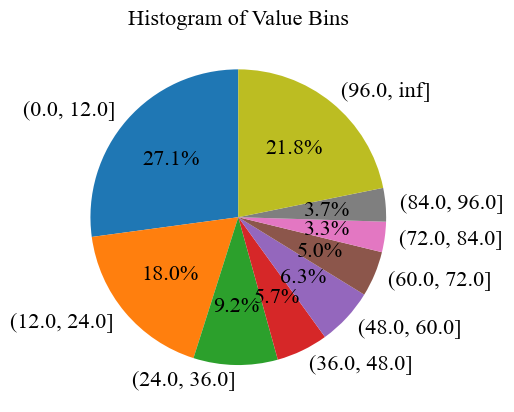

In [58]:
# 视频时长的分布
video_duration_count = pd.cut(video_duration_for_pdf_cdf, bins=list(range(0, 100, 12)).__add__([math.inf])).value_counts()
plt.pie(video_duration_count, labels=video_duration_count.index, autopct='%1.1f%%',
        startangle=90, labeldistance=1.1)
plt.title('Histogram of Value Bins')
plt.show()

del video_duration_count
del video_duration_for_pdf_cdf

In [65]:
play_time_s_for_pdf_cdf = user_info[user_info['video_id'].isin(filtered_video_id_for_pdf_cdf)]['play_time_ms'] / 1000.
play_time_s_for_pdf_cdf = play_time_s_for_pdf_cdf[play_time_s_for_pdf_cdf != 0]
print(play_time_s_for_pdf_cdf.head(10))
print(len(play_time_s_for_pdf_cdf))

1356      16.244
2038      59.068
7191      67.394
7921     169.348
11549      1.636
15453      9.944
17630      1.058
17780     16.444
20999     60.313
21625     13.583
Name: play_time_ms, dtype: float64
43687


In [66]:
# 存储到文件中
file_store_play_time_s = './play_time_in_s'
with open(file_store_play_time_s, 'w') as f:
    for play_time_s in play_time_s_for_pdf_cdf:
        f.write(str(play_time_s) + '\n')

C:\Users\Administrator\AppData\Local\Temp\ipykernel_19060\2111124809.py:172: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from current font.
  plt.savefig(
C:\Users\Administrator\AppData\Local\Temp\ipykernel_19060\2111124809.py:172: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from current font.
  plt.savefig(
C:\Users\Administrator\AppData\Local\Temp\ipykernel_19060\2111124809.py:172: UserWarning: Glyph 23494 (\N{CJK UNIFIED IDEOGRAPH-5BC6}) missing from current font.
  plt.savefig(
C:\Users\Administrator\AppData\Local\Temp\ipykernel_19060\2111124809.py:172: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from current font.
  plt.savefig(
C:\Users\Administrator\AppData\Local\Temp\ipykernel_19060\2111124809.py:172: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-7528}) missing from current font.
  plt.savefig(
C:\Users\Administrator\AppData\Local\Temp\ipykernel_19060\2111124809.py:172: UserWarning: Glyph 25143 (\N{CJK UNIFI

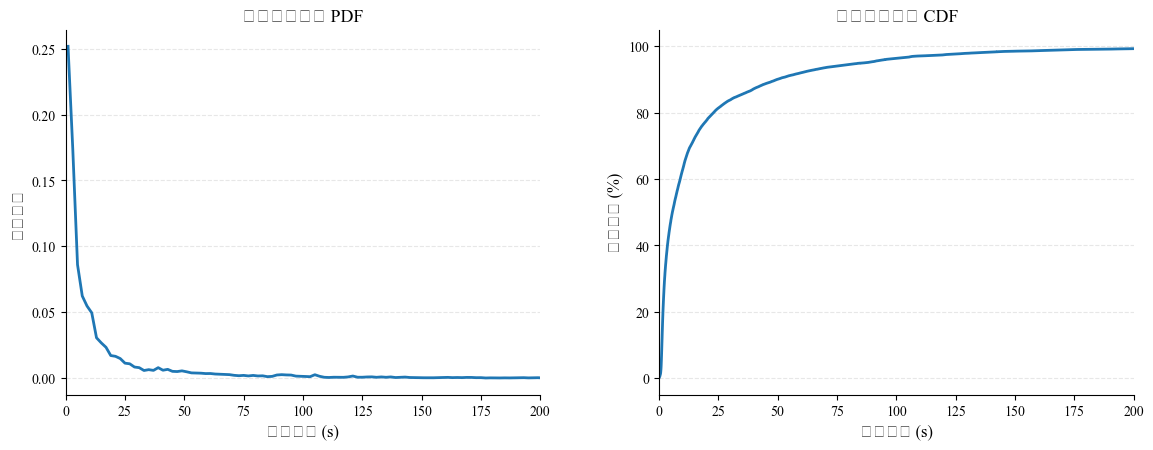

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False

# ============================================================
# 观看时长 PDF / CDF
# ============================================================

duration = pd.Series(play_time_s_for_pdf_cdf)

# ============================================================
# PDF
# ============================================================

# 以 2s 为一个区间
time_interval = 2

bins = np.arange(
    0,
    duration.max() + time_interval,
    time_interval
)

counts, edges = np.histogram(
    duration,
    bins=bins
)

# 概率
pdf = counts / len(duration)

# 使用区间中点作为 X
x_pdf = (
    edges[:-1] + edges[1:]
) / 2


# ============================================================
# CDF
# ============================================================

duration_sorted = np.sort(duration)

cdf = (
    np.arange(1, len(duration_sorted) + 1)
    / len(duration_sorted)
)


# ============================================================
# 绘图
# ============================================================
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)


# ============================================================
# 左图：PDF
# ============================================================
axes[0].plot(
    x_pdf,
    pdf,
    linewidth=2
)

axes[0].set_xlabel(
    '观看时长 (s)',
    fontsize=12
)
axes[0].set_xlim(0, 200)

axes[0].set_ylabel(
    '概率密度',
    fontsize=12
)

axes[0].set_title(
    '用户观看时长 PDF',
    fontsize=13
)

axes[0].grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

axes[0].set_axisbelow(True)

axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)


# ============================================================
# 右图：CDF
# ============================================================

axes[1].plot(
    duration_sorted,
    cdf * 100,
    linewidth=2
)

axes[1].set_xlabel(
    '观看时长 (s)',
    fontsize=12
)

axes[1].set_ylabel(
    '累计概率 (%)',
    fontsize=12
)

axes[1].set_title(
    '用户观看时长 CDF',
    fontsize=13
)

axes[1].set_xlim(
    0,
    200
)

axes[1].grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

axes[1].set_axisbelow(True)

axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)


# ============================================================
# Tick
# ============================================================

for ax in axes:

    ax.tick_params(
        axis='both',
        labelsize=10
    )


# ============================================================
# 布局
# ============================================================

plt.subplots_adjust(
    left=0.08,
    right=0.97,
    bottom=0.15,
    top=0.88,
    wspace=0.25
)


# ============================================================
# 保存
# ============================================================

plt.savefig(
    'user_viewing_duration_pdf_cdf.svg',
    bbox_inches='tight'
)

plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_19060\3906384561.py:169: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from current font.
  plt.savefig('pdf_cdf_network_4G.svg')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_19060\3906384561.py:169: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from current font.
  plt.savefig('pdf_cdf_network_4G.svg')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_19060\3906384561.py:169: UserWarning: Glyph 35266 (\N{CJK UNIFIED IDEOGRAPH-89C2}) missing from current font.
  plt.savefig('pdf_cdf_network_4G.svg')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_19060\3906384561.py:169: UserWarning: Glyph 30475 (\N{CJK UNIFIED IDEOGRAPH-770B}) missing from current font.
  plt.savefig('pdf_cdf_network_4G.svg')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_19060\3906384561.py:169: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from current font.
  plt.savefig('pdf_cdf_network

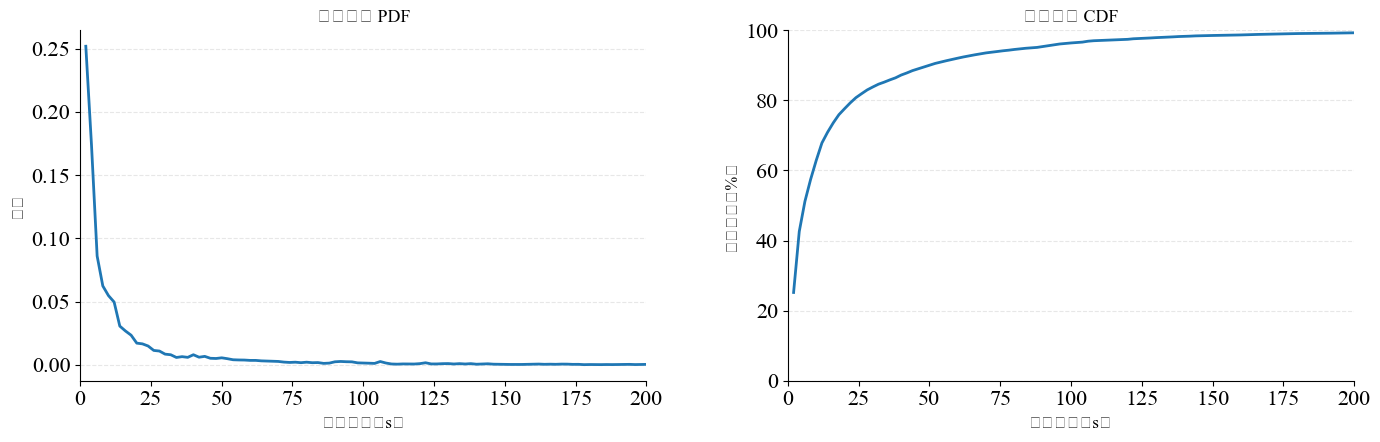


观看时长分位点：
插值后 0% 分位点 ≈ -0.90 秒
插值后 10% 分位点 ≈ 0.25 秒
插值后 20% 分位点 ≈ 1.40 秒
插值后 30% 分位点 ≈ 2.55 秒
插值后 40% 分位点 ≈ 3.70 秒
插值后 50% 分位点 ≈ 5.73 秒
插值后 60% 分位点 ≈ 8.94 秒
插值后 70% 分位点 ≈ 13.41 秒
插值后 80% 分位点 ≈ 22.96 秒
插值后 90% 分位点 ≈ 49.75 秒


In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ============================================================
# 1. 数据处理
# ============================================================

play_time_s_for_pdf_cdf = pd.Series(play_time_s_for_pdf_cdf)

time_interval = 2

bins = list(
    np.arange(
        0,
        1520,
        time_interval
    )
)

play_time_s_for_pdf_cdf = pd.cut(
    play_time_s_for_pdf_cdf,
    bins=bins
).value_counts(
    sort=False
)

play_time_s_for_pdf_cdf.index = list(
    np.arange(
        time_interval,
        play_time_s_for_pdf_cdf.index[-1].right + time_interval,
        time_interval
    )
)

x = play_time_s_for_pdf_cdf.index

# ============================================================
# 2. 计算 PDF 和 CDF
# ============================================================

pdf = (
    play_time_s_for_pdf_cdf.values
    / play_time_s_for_pdf_cdf.sum()
)

cdf = np.cumsum(pdf)


# ============================================================
# 3. 绘图风格
# ============================================================

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False


# ============================================================
# 4. 创建 PDF + CDF 图
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 4.8)
)


# ============================================================
# 5. PDF
# ============================================================

axes[0].plot(
    x,
    pdf,
    linewidth=2
)

axes[0].set_xlabel(
    '观看时长（s）',
    fontsize=12
)

axes[0].set_ylabel(
    '概率',
    fontsize=12
)

axes[0].set_title(
    '观看时长 PDF',
    fontsize=13
)

axes[0].set_xlim(
    0,
    200
)

axes[0].grid(
    axis='y',
    alpha=0.3,
    linestyle='--'
)

# 去掉上、右边框
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)


# ============================================================
# 6. CDF
# ============================================================

axes[1].plot(
    x,
    cdf * 100,
    linewidth=2
)

axes[1].set_xlabel(
    '观看时长（s）',
    fontsize=12
)

axes[1].set_ylabel(
    '累计比例（%）',
    fontsize=12
)

axes[1].set_title(
    '观看时长 CDF',
    fontsize=13
)

axes[1].set_xlim(
    0,
    200
)

axes[1].set_ylim(
    0,
    100
)

axes[1].grid(
    axis='y',
    alpha=0.3,
    linestyle='--'
)

# 去掉上、右边框
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)


# ============================================================
# 7. 布局
# ============================================================

plt.subplots_adjust(
    left=0.07,
    right=0.98,
    bottom=0.15,
    top=0.88,
    wspace=0.25
)

plt.savefig('pdf_cdf_network_4G.svg')
plt.show()


# ============================================================
# 8. 计算分位点
# ============================================================

f = interp1d(
    cdf,
    x,
    kind='linear',
    bounds_error=False,
    fill_value='extrapolate'
)

print('\n观看时长分位点：')

for p in np.arange(0, 1, 0.1):

    x_exact = float(f(p))

    print(
        f'插值后 {p * 100:.0f}% 分位点 ≈ '
        f'{x_exact:.2f} 秒'
    )

In [67]:
# 视频百分比的分布
user_info_for_pdf_cdf = user_info[user_info['video_id'].isin(filtered_video_id_for_pdf_cdf)]
play_percentage_for_pdf_cdf = []
n = len(user_info_for_pdf_cdf)
for i in range(n):
    user_info_col = user_info_for_pdf_cdf.iloc[i]
    # print(user_info_col)
    play_time_ms = user_info_col['play_time_ms']
    video_duration = user_info_col['duration_ms']
    play_percentage = min(play_time_ms / video_duration * 100, 100)
    play_percentage_for_pdf_cdf.append(play_percentage)
    
# play_percentage_for_pdf_cdf = play_percentage_for_pdf_cdf[play_percentage_for_pdf_cdf != 0]
play_percentage_for_pdf_cdf = pd.Series(play_percentage_for_pdf_cdf)
time_interval = 10
bins = list(np.arange(0, 100.9, time_interval))
print(bins)
play_percentage_for_pdf_cdf = pd.cut(play_percentage_for_pdf_cdf, bins=bins).value_counts(sort=False)
play_percentage_for_pdf_cdf.index = list(np.arange(time_interval, play_percentage_for_pdf_cdf.index[-1].right + time_interval, time_interval))
# print(play_time_s_for_pdf_cdf.head(20))

[0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0, 100.0]


In [68]:
# # 存储到文件中
# file_store_play_time_s = './play_percentage'
# with open(file_store_play_time_s, 'w') as f:
#     for play_percentage in play_percentage_for_pdf_cdf:
#         f.write(str(play_percentage) + '\n')

In [70]:
print (play_percentage_for_pdf_cdf.values)


[15101  5808  3258  2207  1646  1352  1240  1095  1228 10752]


C:\Users\Administrator\AppData\Local\Temp\ipykernel_19060\2217475904.py:99: UserWarning: Glyph 25773 (\N{CJK UNIFIED IDEOGRAPH-64AD}) missing from current font.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_19060\2217475904.py:99: UserWarning: Glyph 25918 (\N{CJK UNIFIED IDEOGRAPH-653E}) missing from current font.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_19060\2217475904.py:99: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from current font.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_19060\2217475904.py:99: UserWarning: Glyph 20363 (\N{CJK UNIFIED IDEOGRAPH-4F8B}) missing from current font.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_19060\2217475904.py:99: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-7528}) missing from current font.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_19060\2217475904.py:99: UserWarning: G

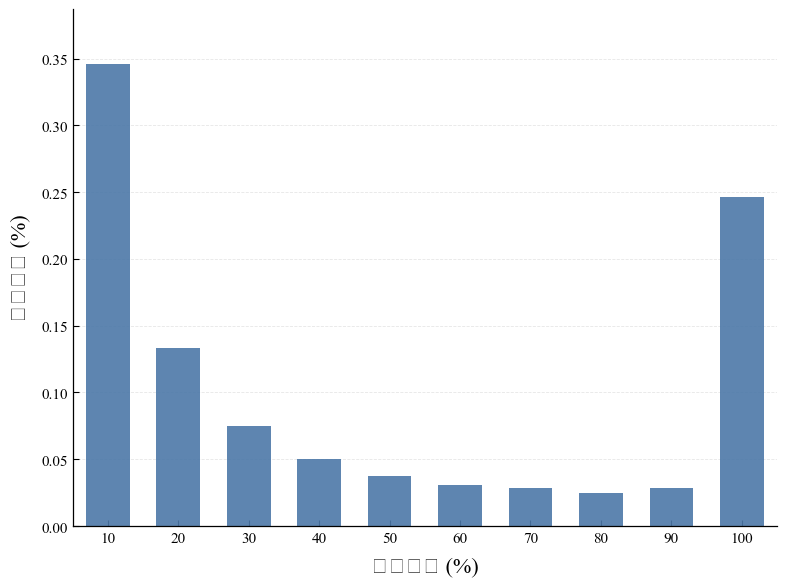

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# 数据
# =========================
x = play_percentage_for_pdf_cdf.index
pdf = play_percentage_for_pdf_cdf.values / play_percentage_for_pdf_cdf.sum()

# 转成 numpy，方便处理
x = np.asarray(x)
pdf = np.asarray(pdf)

# =========================
# 全局字体
# =========================
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 11

# =========================
# 创建图
# =========================
fig, ax = plt.subplots(figsize=(8, 6))

# =========================
# 绘制柱状图
# =========================
ax.bar(
    x,
    pdf,
    width=6.2,              # 增大柱宽
    color='#4C78A8',        # 科研风格蓝色
    edgecolor='none',
    alpha=0.9
)

# =========================
# 坐标轴标签
# =========================
ax.set_xlabel(
    '播放比例 (%)',
    labelpad=8
)

ax.set_ylabel(
    '用户占比 (%)',
    labelpad=8
)

# =========================
# X轴
# =========================
ax.set_xlim(min(x) - 5, max(x) + 5)

# 如果数据是 10,20,...,100
ax.set_xticks(np.arange(10, 101, 10))

# =========================
# Y轴
# =========================
ax.set_ylim(0, max(pdf) * 1.12)

# =========================
# 网格线
# =========================
ax.grid(
    axis='y',
    linestyle='--',
    linewidth=0.6,
    alpha=0.3
)

ax.set_axisbelow(True)

# =========================
# 坐标轴边框
# =========================
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_linewidth(0.9)
ax.spines['bottom'].set_linewidth(0.9)

# =========================
# Tick
# =========================
ax.tick_params(
    axis='both',
    which='major',
    direction='in',
    length=4,
    width=0.8,
    labelsize=11
)

# =========================
# 布局
# =========================
plt.tight_layout()

# =========================
# 保存
# =========================
plt.savefig(
    'playback_time_distribution.svg'
)

plt.show()

In [ ]:
# 观看次数排名前20名视频的id
# print(video_count_id.size)
print(video_count_id.head(10))
random.seed(66)
random_select_video = random.sample(list(video_count_id.head(10000).index), 2000)
print(random_select_video)
# top_80_video = np.array(video_count_id.head(10).index)
# print(top_80_video)

In [ ]:
del video_count_id

In [ ]:
random_sampled_video_dir = './data/random_sampled_video'
if not os.path.exists(random_sampled_video_dir):
    os.makedirs(random_sampled_video_dir)
video_names_file = random_sampled_video_dir + '/video_names.csv'

video_idx = 0
filtered_random_select_video = []
with open(video_names_file, 'w') as f:
    for i in range(len(random_select_video)):
        video_id = random_select_video[i]
        info_video = video_info[video_info['video_id'] == video_id]
        video_duration = info_video['video_duration']
        if not video_duration.empty:
            video_duration = info_video['video_duration'].values[0]
            # print(f'{video_idx},{video_idx}_{video_id},{video_duration},0&1&2\n')
            f.write(f'{video_idx},{video_idx}_{video_id},{video_duration},0&1&2\n')
            filtered_random_select_video.append(video_id)
            video_idx += 1

In [ ]:
print(len(filtered_random_select_video))

In [ ]:
# 算视频聚合
user_info_group_by_video_id = user_info[['video_id', 'play_time_ms']].groupby('video_id')

user_ret_dir = 'data/random_sampled_video/user_ret/'
if not os.path.exists(user_ret_dir):
    os.makedirs(user_ret_dir)
user_switch_prob_dir = 'data/random_sampled_video/user_switch_prob/'
if not os.path.exists(user_switch_prob_dir):
    os.makedirs(user_switch_prob_dir)
sample_user_dir = 'data/random_sampled_video/view_duration/'
if not os.path.exists(sample_user_dir):
    os.makedirs(sample_user_dir)

chunklength = 2000
for index in range(len(filtered_random_select_video)):
    picked_video_id = filtered_random_select_video[index]
    # 以一个视频为例，计算用户留存率
    one_category = user_info_group_by_video_id.get_group(picked_video_id)
    
    picked_video_duration = video_info.at[picked_video_id, 'video_duration']
    
    # picked_video_tag = video_info.at[picked_video_id, 'tag']
    # print('该视频的类型为', picked_video_tag)
    
    print('该视频的时长为', picked_video_duration)
    # 记录所有观看过该视频用户的用户观看时长
    bins = list(range(0, int(picked_video_duration / chunklength) * chunklength + chunklength - 1, chunklength))
    bins.append(math.inf)
    print(bins)
    
    # print(bins)
    user_ret_time = pd.cut(one_category['play_time_ms'], bins=bins).value_counts(sort=False)
    num_user = len(one_category)
    # print('观看过该视频的用户数量为', num_user)
    
    with open(sample_user_dir + str(index) + '_' + str(picked_video_id) , 'w') as f:
        for play_time_ms in one_category['play_time_ms']:
            view_duration = min(play_time_ms, picked_video_duration)
            f.write(str(view_duration) + '\n')
    
    # 记录该视频的用户留存率  
    user_ret_time = pd.concat([pd.Series([0]), user_ret_time], axis=0)
    user_ret_time.iloc[0] = num_user
    for i in range(1, len(bins)):
        num_user = num_user - user_ret_time.iloc[i]
        user_ret_time.iloc[i] = num_user
    
    user_ret_time = user_ret_time / len(one_category)
    user_ret_time.index = [i * 1.0 for i in range(len(user_ret_time))]
    # print(user_ret_time)
    
    with open(user_ret_dir + str(index) + '_' + str(picked_video_id) , 'w', newline='') as f:
        for i in range(len(user_ret_time)):
            f.write(str(i * chunklength / 1000) + '\t' + str(user_ret_time[i]) + '\n')
    
    # 记录该视频的滑动概率分布
    bins = list(range(0, int(picked_video_duration / 1000) * 1000 + 1000 - 1, 1000))
    bins.append(math.inf)
    print(bins)
    user_ret_time = pd.cut(one_category['play_time_ms'], bins=bins).value_counts(sort=False)
    num_user = len(one_category)
    
    user_switch_prop = user_ret_time / num_user
    user_switch_prop.index = [i * 1.0 for i in range(len(user_switch_prop))]
    print('用户的滑动概率分布为：')
    print(user_switch_prop)
    with open(user_switch_prob_dir + str(index) + '_' + str(picked_video_id), 'w') as f:
        for i in range(len(user_switch_prop)):
            f.write(str(user_switch_prop[i]) + '\n')
            
del user_info_group_by_video_id